<a href="https://colab.research.google.com/github/cduplan59/CFT_analysis/blob/main/ROSG_Test4_vertical_spectral_channel_audit_FIXED_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ROSG — Test4: Vertical spectral channel audit

**Goal.** Add a Bianconi-inspired channel-isolation layer on top of the existing ROSG Test1–Test3 chain.

This notebook does **not** replace Test1, Test2 or Test3. It uses their GitHub/Zenodo outputs to test whether the spectral crossover is carried by a robust effective vertical/multiplex channel.

Existing chain:

\[
\text{Test1: }K_n^{cell4}\to \mathcal E_Z\to L_Z\to P(u;Z)\to d_s^{eff}(Z)
\]

\[
\text{Test2: }g_\perp^{eff}(Z)\to m_\perp^{RG}(Z)
\]

\[
\text{Test3: }m_\perp^{RG}(Z)\to L(Z)\to P(u;Z)\to d_s^{eff}(Z)
\]

Test4 adds:

\[
L_Z^{tot}\approx L_Z^{2D}+\eta_\perp(Z)L_Z^\perp
\]

and audits the effective lift:

\[
\Delta_\perp d_s = d_s^{tot}-d_s^{2D}.
\]

In [1]:
# ============================================================
# 0. Imports and source URLs
# ============================================================
import os, json, zipfile, shutil, hashlib, math, urllib.request, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

ZENODO_TEST1 = 'https://zenodo.org/records/20315578/files/ROSG_Test1K_Merged_Audit_EN.zip?download=1'
ZENODO_TEST2 = 'https://zenodo.org/records/20315578/files/ROSG_Test2bis_RG_Conductances_Audit_EN.zip?download=1'
ZENODO_TEST3 = 'https://zenodo.org/records/20315578/files/ROSG_Test3_Test3bis_Merged_Audit_EN.zip?download=1'

GITHUB_TEST1 = 'https://github.com/cduplan59/CFT_analysis/blob/main/cell4_spectral_dimension_robustness_colab_nreal50_TEST1K_DRIVE_RESUME_V3.ipynb'
GITHUB_TEST2 = 'https://github.com/cduplan59/CFT_analysis/blob/main/piste2bis_rg_conductances_cell4_colab_CHECKPOINT_DRIVE_N50.ipynb'
GITHUB_TEST3 = 'https://github.com/cduplan59/CFT_analysis/blob/main/piste3bis_derive_heat_kernel_broadening_colab_ZIP_EXPORT.ipynb'

OUTDIR = Path('/content/ROSG_Test4_vertical_spectral_channel_audit')
OUTDIR.mkdir(parents=True, exist_ok=True)
(OUTDIR/'figures').mkdir(exist_ok=True)

print('Test4 output directory:', OUTDIR)
print('GitHub Test1:', GITHUB_TEST1)
print('GitHub Test2:', GITHUB_TEST2)
print('GitHub Test3:', GITHUB_TEST3)

Test4 output directory: /content/ROSG_Test4_vertical_spectral_channel_audit
GitHub Test1: https://github.com/cduplan59/CFT_analysis/blob/main/cell4_spectral_dimension_robustness_colab_nreal50_TEST1K_DRIVE_RESUME_V3.ipynb
GitHub Test2: https://github.com/cduplan59/CFT_analysis/blob/main/piste2bis_rg_conductances_cell4_colab_CHECKPOINT_DRIVE_N50.ipynb
GitHub Test3: https://github.com/cduplan59/CFT_analysis/blob/main/piste3bis_derive_heat_kernel_broadening_colab_ZIP_EXPORT.ipynb


In [2]:
# ============================================================
# 1. Locate or download Test1K result ZIP (cache-first)
# ============================================================
USE_GOOGLE_DRIVE = True
DRIVE_CANDIDATES = [
    '/content/drive/MyDrive/ROSG_exports/ROSG_Test1K_Merged_Audit_EN.zip',
    '/content/drive/MyDrive/DFGQ_Test1K/ROSG_Test1K_Merged_Audit_EN.zip',
    '/content/drive/MyDrive/ROSG_Test1K_Merged_Audit_EN.zip',
]
LOCAL_ZIP = Path('/content/ROSG_Test1K_Merged_Audit_EN.zip')

if USE_GOOGLE_DRIVE:
    try:
        from google.colab import drive
        drive.mount('/content/drive', force_remount=False)
    except Exception as exc:
        print('Drive mount skipped/failed:', exc)

input_zip = None
for p in DRIVE_CANDIDATES:
    if Path(p).exists():
        input_zip = Path(p)
        print('Using Drive ZIP:', input_zip)
        break

if input_zip is None and LOCAL_ZIP.exists():
    input_zip = LOCAL_ZIP
    print('Using local ZIP:', input_zip)

if input_zip is None:
    print('Downloading Test1K ZIP from Zenodo...')
    urllib.request.urlretrieve(ZENODO_TEST1, LOCAL_ZIP)
    input_zip = LOCAL_ZIP
    print('Downloaded:', input_zip, input_zip.stat().st_size, 'bytes')

print('Input SHA256:', hashlib.sha256(open(input_zip,'rb').read()).hexdigest())

Mounted at /content/drive
Using Drive ZIP: /content/drive/MyDrive/DFGQ_Test1K/ROSG_Test1K_Merged_Audit_EN.zip
Input SHA256: 690c125f443d5af08522790d5145b42542d8999b3986c5ded83555aaaa71eab8


In [3]:
# ============================================================
# 2. Read Test1K refit outputs
# ============================================================
def read_zip_csv(zp, path):
    with zipfile.ZipFile(zp) as z:
        return pd.read_csv(z.open(path))

def zip_names(zp):
    with zipfile.ZipFile(zp) as z:
        return z.namelist()

names = zip_names(input_zip)
best_path = '02_final_refit_analysis/FINAL_refit_best_sigmoid_by_estimator.csv'
detailed_path = '02_final_refit_analysis/FINAL_refit_detailed_models_all_estimators.csv'
review_path = '02_final_refit_analysis/FINAL_refit_reviewer_safe_summary.csv'

best = read_zip_csv(input_zip, best_path)
detailed = read_zip_csv(input_zip, detailed_path)
review = read_zip_csv(input_zip, review_path)

print('best rows:', len(best))
display(best.head())

best rows: 60


,tag,is_publication_variant,y_col,best_aic_model,best_sigmoid_like_model,delta_aic_constant_vs_best_sigmoid,delta_aic_linear_vs_best_sigmoid,delta_aic_pure_power_vs_best_sigmoid,d_uv,d_ir,Z_th,Delta_Z,hill_p,uv_mean_minus_median_first3,n_Z
0,base_kigami_p24,False,ds_mean,hill_saturating_power,hill_saturating_power,112.758193,79.670820,81.553515,1.813519,2.380238,1.887266,0.662575,3.018525,-0.267759,17
1,base_kigami_p24,False,ds_median,logistic,logistic,59.617373,23.056937,24.923419,2.062867,2.562454,1.605083,1.085088,NaN,-0.267759,17
2,base_kigami_p24,False,ds_trimmed_mean,logistic,logistic,112.984492,79.931136,81.803807,1.815202,2.379446,1.887703,0.659219,NaN,-0.267759,17
3,comparison_phenomenological,False,ds_mean,hill_saturating_power,hill_saturating_power,126.293214,92.369213,94.192453,1.812541,2.407040,1.892243,0.676173,2.957821,-0.264161,17
4,comparison_phenomenological,False,ds_median,hill_saturating_power,hill_saturating_power,68.933835,29.051852,31.038748,2.060066,2.663102,1.780167,1.149668,1.739632,-0.264161,17


In [4]:
# ============================================================
# 3. Primary vertical-channel audit from refit summaries
# ============================================================
PRIMARY = 'ds_median'
primary = best[best['y_col'] == PRIMARY].copy()
plane = primary[primary['tag'] == 'negative_plane2d'].iloc[0]
plane_duv = float(plane['d_uv'])
plane_dir = float(plane['d_ir'])
plane_delta = plane_dir - plane_duv

rows = []
for _, r in primary.iterrows():
    tag = r['tag']
    if tag == 'negative_plane2d':
        category = '2D_negative_control'
    elif 'phenomenological' in tag:
        category = 'multiplex_phenomenological'
    elif bool(r.get('is_publication_variant')) or str(tag).startswith('pub_'):
        category = 'multiplex_publication_variant'
    else:
        category = 'multiplex_structured_or_internal'
    duv = float(r['d_uv']); dir_ = float(r['d_ir']); delta = dir_ - duv
    lift_ir = dir_ - plane_dir
    lift_delta = delta - plane_delta
    uv_drift = abs(duv - plane_duv)
    strong_sig_const = float(r['delta_aic_constant_vs_best_sigmoid']) > 10
    strong_sig_linear = float(r['delta_aic_linear_vs_best_sigmoid']) > 6
    robust_vertical = (tag != 'negative_plane2d') and (lift_ir > 0.25) and (lift_delta > 0.25) and strong_sig_const and strong_sig_linear
    rows.append({
        'tag': tag,
        'category': category,
        'is_publication_variant': bool(r.get('is_publication_variant')),
        'estimator': PRIMARY,
        'd_uv': duv,
        'd_ir': dir_,
        'delta_ds': delta,
        'plane2d_d_uv_reference': plane_duv,
        'plane2d_d_ir_reference': plane_dir,
        'plane2d_delta_ds_reference': plane_delta,
        'vertical_lift_IR_vs_plane2d': lift_ir,
        'vertical_lift_delta_vs_plane2d': lift_delta,
        'uv_drift_vs_plane2d': uv_drift,
        'Z_th': float(r['Z_th']),
        'Delta_Z': float(r['Delta_Z']),
        'delta_aic_constant_vs_best_sigmoid': float(r['delta_aic_constant_vs_best_sigmoid']),
        'delta_aic_linear_vs_best_sigmoid': float(r['delta_aic_linear_vs_best_sigmoid']),
        'strong_sigmoid_vs_constant': strong_sig_const,
        'strong_sigmoid_vs_linear': strong_sig_linear,
        'robust_vertical_channel_candidate': robust_vertical,
    })

channel_df = pd.DataFrame(rows)
channel_df.to_csv(OUTDIR/'test4_vertical_channel_summary.csv', index=False)
display(channel_df)

,tag,category,is_publication_variant,estimator,d_uv,d_ir,delta_ds,plane2d_d_uv_reference,plane2d_d_ir_reference,plane2d_delta_ds_reference,vertical_lift_IR_vs_plane2d,vertical_lift_delta_vs_plane2d,uv_drift_vs_plane2d,Z_th,Delta_Z,delta_aic_constant_vs_best_sigmoid,delta_aic_linear_vs_best_sigmoid,strong_sigmoid_vs_constant,strong_sigmoid_vs_linear,robust_vertical_channel_candidate
0,base_kigami_p24,multiplex_structured_or_internal,False,ds_median,2.062867,2.562454,0.499587,2.103607,2.092786,-0.010821,0.469669,0.510408,0.040739,1.605083,1.085088,59.617373,23.056937,True,True,True
1,comparison_phenomenological,multiplex_phenomenological,False,ds_median,2.060066,2.663102,0.603036,2.103607,2.092786,-0.010821,0.570317,0.613857,0.043540,1.780167,1.149668,68.933835,29.051852,True,True,True
2,layers12_torus,multiplex_structured_or_internal,False,ds_median,2.061517,2.660698,0.599181,2.103607,2.092786,-0.010821,0.567912,0.610002,0.042090,1.756942,1.085672,66.615642,28.969061,True,True,True
3,main_kigami_local,multiplex_structured_or_internal,False,ds_median,2.056870,2.564854,0.507983,2.103607,2.092786,-0.010821,0.472068,0.518804,0.046736,1.587797,1.139727,60.252630,22.849548,True,True,True
4,negative_plane2d,2D_negative_control,False,ds_median,2.103607,2.092786,-0.010821,2.103607,2.092786,-0.010821,0.000000,0.000000,0.000000,0.857390,0.037150,-0.547467,-0.048894,False,False,False
5,pub_layers12_torus0_p32,multiplex_publication_variant,True,ds_median,2.058031,2.604979,0.546948,2.103607,2.092786,-0.010821,0.512193,0.557769,0.045576,1.696990,1.213084,82.962041,35.962764,True,True,True
6,pub_layers12_torus0_p64,multiplex_publication_variant,True,ds_median,2.057556,2.603819,0.546263,2.103607,2.092786,-0.010821,0.511034,0.557084,0.046051,1.697842,1.181298,81.918073,35.838907,True,True,True
7,pub_layers12_torus1_p32,multiplex_publication_variant,True,ds_median,2.068315,2.664420,0.596106,2.103607,2.092786,-0.010821,0.571635,0.606927,0.035292,1.798101,1.063762,84.823103,40.825930,True,True,True
8,pub_layers12_torus1_p64,multiplex_publication_variant,True,ds_median,2.061536,2.677014,0.615478,2.103607,2.092786,-0.010821,0.584228,0.626299,0.042071,1.809959,1.132055,86.835988,40.686472,True,True,True
9,pub_layers16_torus0_p32,multiplex_publication_variant,True,ds_median,2.060837,2.625665,0.564829,2.103607,2.092786,-0.010821,0.532880,0.575650,0.042770,1.748896,1.183175,84.794199,38.123504,True,True,True


In [5]:
# ============================================================
# 4. Per-Z lift and vertical-edge correlation when aggregated data exist
# ============================================================
agg_map = {}
with zipfile.ZipFile(input_zip) as z:
    for p in names:
        if p.endswith('_aggregated.csv'):
            tag = Path(p).name.replace('_aggregated.csv','')
            try:
                df = pd.read_csv(z.open(p))
                if {'Z','ds_mean','ds_median'}.issubset(df.columns):
                    agg_map[tag] = df
            except Exception:
                pass

plane_agg = agg_map.get('negative_plane2d')
perz_rows = []
for tag, df in agg_map.items():
    if tag == 'negative_plane2d':
        continue
    for ycol in [c for c in ['ds_mean','ds_median','ds_trimmed_mean'] if c in df.columns]:
        if plane_agg is not None and ycol in plane_agg.columns:
            baseline = np.interp(df['Z'].values, plane_agg['Z'].values, plane_agg[ycol].values)
            lift = df[ycol].values - baseline
        else:
            baseline = np.full(len(df), plane_duv)
            lift = df[ycol].values - baseline
        corr = np.nan
        if 'E_vertical' in df.columns:
            corr = float(np.corrcoef(df['E_vertical'].values, df[ycol].values)[0,1])
        perz_rows.append({
            'tag': tag,
            'estimator': ycol,
            'n_Z': len(df),
            'mean_vertical_lift_vs_plane_reference': float(np.nanmean(lift)),
            'min_vertical_lift_vs_plane_reference': float(np.nanmin(lift)),
            'max_vertical_lift_vs_plane_reference': float(np.nanmax(lift)),
            'corr_E_vertical_vs_ds': corr,
            'E_vertical_min': float(df['E_vertical'].min()) if 'E_vertical' in df.columns else np.nan,
            'E_vertical_max': float(df['E_vertical'].max()) if 'E_vertical' in df.columns else np.nan,
        })
        if ycol == PRIMARY:
            out = pd.DataFrame({'Z': df['Z'].values, f'{tag}_{ycol}': df[ycol].values, 'plane_reference': baseline, 'vertical_lift': lift})
            out.to_csv(OUTDIR/f'perZ_lift_{tag}_{ycol}.csv', index=False)

perz_df = pd.DataFrame(perz_rows)
perz_df.to_csv(OUTDIR/'test4_perZ_channel_lift_and_correlation.csv', index=False)
display(perz_df.head(20))

,tag,estimator,n_Z,mean_vertical_lift_vs_plane_reference,min_vertical_lift_vs_plane_reference,max_vertical_lift_vs_plane_reference,corr_E_vertical_vs_ds,E_vertical_min,E_vertical_max
0,pub_layers12_torus0_p32,ds_mean,21,0.021624,-0.288995,0.318290,0.993123,0.0,2816.0
1,pub_layers12_torus0_p32,ds_median,21,0.250338,-0.030287,0.495125,0.966249,0.0,2816.0
2,pub_layers12_torus0_p64,ds_mean,21,0.022157,-0.287138,0.318896,0.993184,0.0,2816.0
3,pub_layers12_torus0_p64,ds_median,21,0.249446,-0.030321,0.494658,0.966398,0.0,2816.0
4,pub_layers12_torus1_p32,ds_mean,21,0.062924,-0.287857,0.406209,0.994554,0.0,2816.0
5,pub_layers12_torus1_p32,ds_median,21,0.279103,-0.027322,0.570160,0.977984,0.0,2816.0
6,pub_layers12_torus1_p64,ds_mean,21,0.064570,-0.288915,0.406480,0.994878,0.0,2816.0
7,pub_layers12_torus1_p64,ds_median,21,0.281534,-0.033403,0.566845,0.977730,0.0,2816.0
8,pub_layers16_torus0_p32,ds_mean,21,0.032615,-0.287560,0.342365,0.993815,0.0,3840.0
9,pub_layers16_torus0_p32,ds_median,21,0.258863,-0.029145,0.515351,0.971354,0.0,3840.0


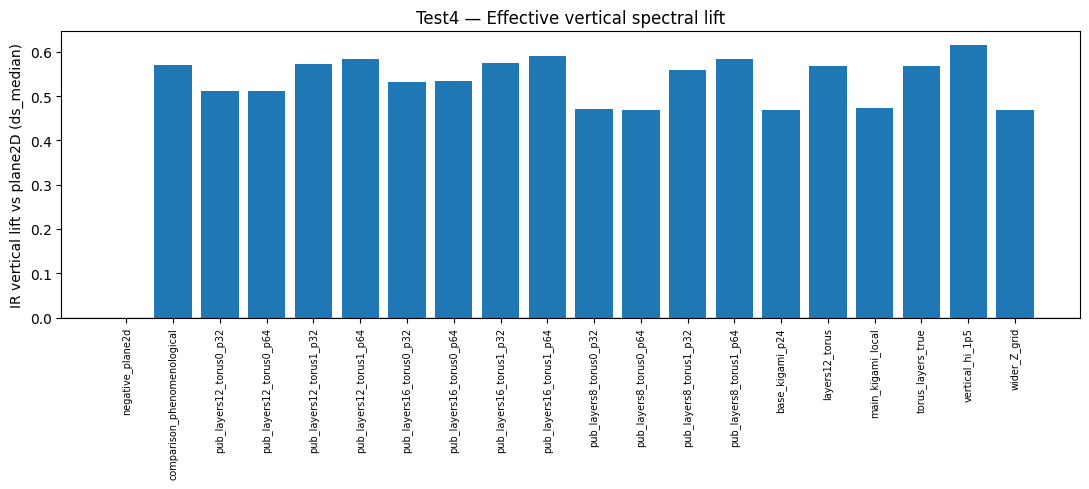

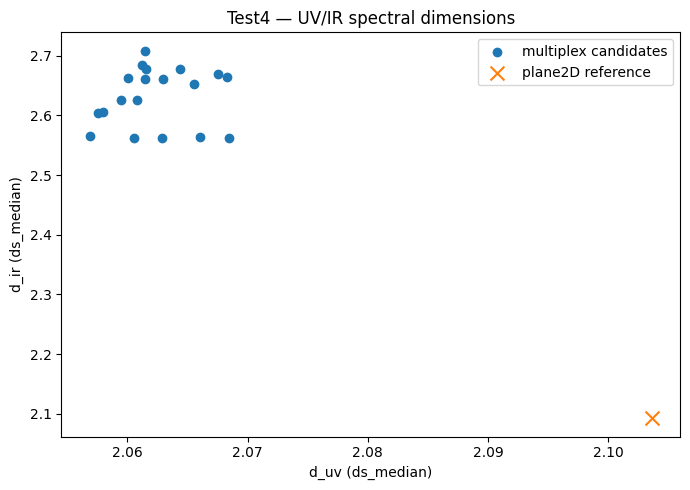

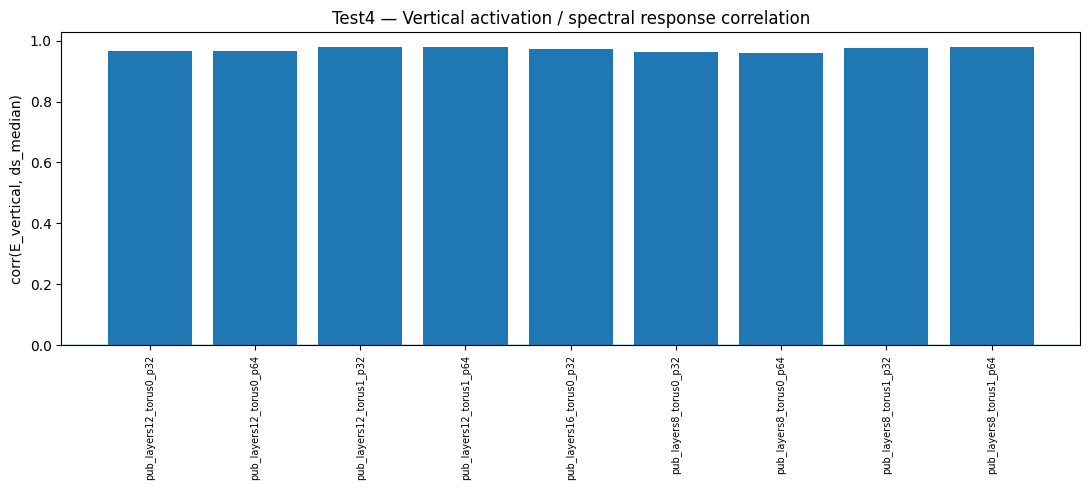

In [6]:
# ============================================================
# 5. Figures
# ============================================================
plot_df = channel_df.sort_values(['category','tag']).copy()
plt.figure(figsize=(11,5))
plt.bar(range(len(plot_df)), plot_df['vertical_lift_IR_vs_plane2d'].values)
plt.axhline(0, linewidth=1)
plt.xticks(range(len(plot_df)), plot_df['tag'].values, rotation=90, fontsize=7)
plt.ylabel('IR vertical lift vs plane2D (ds_median)')
plt.title('Test4 — Effective vertical spectral lift')
plt.tight_layout()
plt.savefig(OUTDIR/'figures/test4_vertical_lift_bar.png', dpi=180)
plt.show()

multiplex = channel_df[channel_df['tag']!='negative_plane2d']
plt.figure(figsize=(7,5))
plt.scatter(multiplex['d_uv'], multiplex['d_ir'], label='multiplex candidates')
plt.scatter([plane_duv], [plane_dir], marker='x', s=100, label='plane2D reference')
plt.xlabel('d_uv (ds_median)')
plt.ylabel('d_ir (ds_median)')
plt.title('Test4 — UV/IR spectral dimensions')
plt.legend()
plt.tight_layout()
plt.savefig(OUTDIR/'figures/test4_duv_dir_scatter.png', dpi=180)
plt.show()

if len(perz_df):
    cdf = perz_df[(perz_df['estimator']==PRIMARY)&np.isfinite(perz_df['corr_E_vertical_vs_ds'])]
    if len(cdf):
        plt.figure(figsize=(11,5))
        plt.bar(range(len(cdf)), cdf['corr_E_vertical_vs_ds'].values)
        plt.axhline(0, linewidth=1)
        plt.xticks(range(len(cdf)), cdf['tag'].values, rotation=90, fontsize=7)
        plt.ylabel('corr(E_vertical, ds_median)')
        plt.title('Test4 — Vertical activation / spectral response correlation')
        plt.tight_layout()
        plt.savefig(OUTDIR/'figures/test4_corr_Evertical_ds.png', dpi=180)
        plt.show()

In [7]:
# ============================================================
# 6. Export report, README, manifest and ZIP — FIXED V2
# ============================================================
from pathlib import Path
import json, hashlib, shutil
import pandas as pd

multiplex = channel_df[channel_df['tag']!='negative_plane2d']
robust_n = int(multiplex['robust_vertical_channel_candidate'].sum())
report = {
    'test_name': 'ROSG Test4 — Vertical spectral channel audit',
    'status': 'completed_from_Test1K_cache',
    'source_method': 'cache-first audit from Test1K refit and checkpoint outputs; no heavy heat-trace recomputation',
    'github_test1': GITHUB_TEST1,
    'github_test2': GITHUB_TEST2,
    'github_test3': GITHUB_TEST3,
    'zenodo_test1': ZENODO_TEST1,
    'zenodo_test2': ZENODO_TEST2,
    'zenodo_test3': ZENODO_TEST3,
    'primary_estimator': PRIMARY,
    'plane2d_reference': {'d_uv': plane_duv, 'd_ir': plane_dir, 'delta_ds': plane_delta},
    'n_multiplex_candidates': int(len(multiplex)),
    'n_robust_vertical_channel_candidates': robust_n,
    'fraction_robust_vertical_channel_candidates': float(robust_n / max(len(multiplex), 1)),
    'mean_vertical_lift_IR_vs_plane2d': float(multiplex['vertical_lift_IR_vs_plane2d'].mean()),
    'min_vertical_lift_IR_vs_plane2d': float(multiplex['vertical_lift_IR_vs_plane2d'].min()),
    'max_vertical_lift_IR_vs_plane2d': float(multiplex['vertical_lift_IR_vs_plane2d'].max()),
    'mean_vertical_lift_delta_vs_plane2d': float(multiplex['vertical_lift_delta_vs_plane2d'].mean()),
    'min_vertical_lift_delta_vs_plane2d': float(multiplex['vertical_lift_delta_vs_plane2d'].min()),
    'max_vertical_lift_delta_vs_plane2d': float(multiplex['vertical_lift_delta_vs_plane2d'].max()),
    'interpretation': 'Multiplex variants are compared to the plane2D negative control. Positive lift plus strong sigmoid model selection supports an effective vertical spectral channel.',
    'limitations': [
        'Existing cache isolates channel by comparison/subtraction against plane2D rather than explicit independent construction of L_perp.',
        'A future full Test4 should compute L_2D, L_perp_structured, L_perp_random and L_total on identical graph instances.',
        'DSI is not claimed here; this prepares the channel-isolation layer required before a DSI/log-periodic residual audit.'
    ]
}
with open(OUTDIR/'test4_vertical_channel_report.json','w',encoding='utf-8') as f:
    json.dump(report, f, indent=2, ensure_ascii=False)

readme = f"""# ROSG Test4 — Vertical spectral channel audit

This package is a cache-first Test4 built on the existing GitHub/Zenodo ROSG test chain.

Primary estimator: `{PRIMARY}`.

Plane2D reference: d_uv={plane_duv:.6f}, d_ir={plane_dir:.6f}, delta_ds={plane_delta:.6f}.

Multiplex candidates audited: {len(multiplex)}.
Robust vertical channel candidates: {robust_n}/{len(multiplex)}.
Mean IR lift vs plane2D: {report['mean_vertical_lift_IR_vs_plane2d']:.6f}.

This audit does not claim DSI. It prepares the channel-isolation layer needed before a DSI/log-periodic residual test.
"""
(OUTDIR/'README.md').write_text(readme, encoding='utf-8')

manifest_rows=[]
for p in sorted(OUTDIR.rglob('*')):
    if p.is_file():
        manifest_rows.append({
            'path': str(p.relative_to(OUTDIR)),
            'size_bytes': p.stat().st_size,
            'sha256': hashlib.sha256(p.read_bytes()).hexdigest()
        })
pd.DataFrame(manifest_rows).to_csv(OUTDIR/'manifest.csv', index=False)

zip_path = shutil.make_archive('/content/ROSG_Test4_vertical_spectral_channel_audit_results', 'zip', OUTDIR)
print('Exported ZIP:', zip_path)

# Optional Drive mirror
try:
    drive_out = Path('/content/drive/MyDrive/ROSG_exports/Test4_vertical_spectral_channel')
    drive_out.mkdir(parents=True, exist_ok=True)
    shutil.copy2(zip_path, drive_out/Path(zip_path).name)
    print('Copied ZIP to Drive:', drive_out/Path(zip_path).name)
except Exception as exc:
    print('Drive copy skipped:', exc)



Exported ZIP: /content/ROSG_Test4_vertical_spectral_channel_audit_results.zip
Copied ZIP to Drive: /content/drive/MyDrive/ROSG_exports/Test4_vertical_spectral_channel/ROSG_Test4_vertical_spectral_channel_audit_results.zip


## Next step: full Bianconi-style channel decomposition

This cache-first Test4 isolates the vertical contribution by comparison with the plane2D negative control. A stronger full Test4 should recompute on identical graph instances:

\[
L_Z^{2D},\quad L_Z^{\perp,structured},\quad L_Z^{\perp,random},\quad L_Z^{tot}.
\]

Then compare:

\[
d_s^{2D}(Z),\quad d_s^{random}(Z),\quad d_s^{structured}(Z),\quad d_s^{tot}(Z).
\]

Only after this channel is isolated should a Test5 search for a log-periodic/DSI residual:

\[
d_s^{tot}(Z)=d_s^{sigmoid}(Z)+A\cos(\omega Z+\phi)+\epsilon.
\]